**ФИО : Ле Ньы Нгок**

**МПИ-25-1-2**

# Домашка

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.

In [ ]:
# Базовые библиотеки
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from typing import List, Tuple

from datasets import load_dataset

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Часть A — Domain shift и различия распределений


## A1) Был выбран датасет с категориями: https://huggingface.co/datasets/data-silence/rus_news_classifier

In [ ]:
TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens: List[str], chunk_size: int = 200, min_frac: float = 0.5) -> List[str]:
    """Режем на чанки фиксированной длины; хвост сохраняем, если он >= min_frac*chunk_size."""
    chunks = []
    min_len = int(chunk_size * min_frac)
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))
    return chunks

def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}
    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)
    return deltas

def top_log_odds_words(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(simple_tokenize(t))
    for t in texts_b:
        cb.update(simple_tokenize(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

def plot_length_hist(texts: List[str], title: str):
    lens = [len(simple_tokenize(t)) for t in texts]
    plt.figure()
    plt.hist(lens, bins=50, alpha=0.75)
    plt.title(title)
    plt.xlabel("длина документа (токены)")
    plt.ylabel("кол-во")
    plt.show()

In [ ]:
ds = load_dataset("data-silence/rus_news_classifier")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/57530 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14383 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

In [ ]:
print(ds["train"].features)
print(ds["train"][0].keys())
print("Пример текста:\n", ds["train"][1]["news"][:150])
print("label:", ds["train"][1]["labels"])

{'news': Value('string'), 'labels': Value('int32')}
dict_keys(['news', 'labels'])
Пример текста:
 В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров. Об этом сообщает издание Windows Latest. Журналисты выяснили, что
label: 7


Для анализа выбраны две темы вручную: тема 7 и тема 9. Это сделано для сравнения контента разных категорий (например, культурные/социальные новости vs спортивные новости).

categories_translator =
{'climate': 0,
 'conflicts': 1,
 'culture': 2,
 'economy': 3,
 'gloss': 4,
 'health': 5,
 'politics': 6,
 '**science': 7**,
 'society': 8,
 '**sports': 9**,
 'travel': 10}

In [ ]:
selected_labels = [7, 9]

filtered_data = [ex for ex in ds["train"] if ex["labels"] in selected_labels]

domain1 = [ex["news"] for ex in filtered_data if ex["labels"] == selected_labels[0]]
domain2 = [ex["news"] for ex in filtered_data if ex["labels"] == selected_labels[1]]

print(f"Domain {selected_labels[0]}: {len(domain1)} samples")
print(f"Domain {selected_labels[1]}: {len(domain2)} samples")

Domain 7: 5406 samples
Domain 9: 4791 samples


In [ ]:
label_science = 7
label_sports = 9
(label_science, label_sports)

(7, 9)

 Несколько примеров из каждого класса

In [ ]:
text_science = [i["news"] for i in ds["train"] if i["labels"]==label_science]
text_sports = [i["news"] for i in ds["train"] if i["labels"]==label_sports]
print(label_science, text_science[3][:500])
print(label_sports, text_sports[5][:500])

7 Корпорация Microsoft изменила правила вставки текста и изображений в документ Word. Об этом сообщается в блоге компании.Функция Merge formatting позволит вставлять текст или изображения с применением 
['Британский боксер-тяжеловес Тайсон Фьюри оскорбил украинца Александра Усика. Его слова приводит Daily Mail. Спортсмен назвал возможного соперника маленьким украинским бомжом и заявил, что ему не интересен бой с ним. «Это единственное, кем он для меня является. Мне не нужны все пояса этого дивизиона. Вся эта чушь меня не интересует», — подчеркнул он. 14 сентября Фьюри заявил, что больше не желает драться с Усиком. Бой между британцем и украинцем неоднократно срывался. Стороны не смогли договориться о распределении гонораров. На счету Усика 21 победа в 21 поединке. Он удерживает чемпионские пояса Всемирной боксерской организации (WBO), Международной боксерской федерации (IBF), Международной боксерской организации (IBO) и WBA Super в супертяжелом весе. В активе Фьюри 33 победы, одна ничь

## A2) top-30 log-odds токенов (в обе стороны).

In [22]:
cnt_science = Counter()
for t in text_science:
  cnt_science.update(simple_tokenize(t))

N_tokens = sum(cnt_science.values())  # tokens = все употребления
V_types = len(cnt_science)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-30
top30 = cnt_science.most_common(30)
top30[:10]

Tokens (всего словоупотреблений): 887,743
Types  (уникальных слов):        66,802


[('в', 40242),
 ('и', 20116),
 ('на', 19598),
 ('что', 15752),
 ('с', 11862),
 ('по', 8522),
 ('для', 7192),
 ('не', 5841),
 ('из', 5269),
 ('этом', 4717)]

In [23]:
cnt_sports = Counter()
for t in text_sports:
  cnt_sports.update(simple_tokenize(t))

N_tokens = sum(cnt_sports.values())  # tokens = все употребления
V_types = len(cnt_sports)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-30
top30 = cnt_sports.most_common(30)
top30[:10]

Tokens (всего словоупотреблений): 609,743
Types  (уникальных слов):        43,660


[('в', 32253),
 ('на', 13158),
 ('и', 12488),
 ('что', 8637),
 ('с', 7411),
 ('по', 6031),
 ('не', 5681),
 ('он', 4858),
 ('за', 4323),
 ('россии', 3528)]

In [25]:
pos, neg = top_log_odds_words(text_science, text_sports, top_n=30, alpha=0.1)
print("Топ-слова для science (против sci):")
display(pd.DataFrame(pos, columns=["word", "Δ(sci-spo)"]))
print("Топ-слова для sport (против spo):")
display(pd.DataFrame(neg, columns=["word", "Δ(sci-spo)"]))

Топ-слова для science (против sci):


,word,Δ(sci-spo)
0,ос,8.941956
1,смартфонов,8.681602
2,журнале,8.400959
3,пк,8.348449
4,ии,8.296477
5,корпорация,8.270324
6,исследователи,8.259669
7,аппарат,8.257882
8,устройство,8.243470
9,космического,8.117968


Топ-слова для sport (против spo):


,word,Δ(sci-spo)
0,нхл,-9.625484
1,счетом,-9.390332
2,турнире,-9.297814
3,хоккейной,-9.264055
4,чемпионате,-9.224840
5,олимпиаде,-9.211901
6,спортсменка,-9.119495
7,олимпийского,-9.029898
8,побед,-8.998155
9,поединок,-8.916034


## А3) 2 графика распределений:
длина документов,
Zipf (частоты топ-100 токенов),

In [26]:
label_names = [
    "climate", "conflicts", "culture", "economy", "gloss",
    "health", "politics", "science", "society", "sports", "travel"
]
df_len = pd.DataFrame({
    "len_tokens": [len(simple_tokenize(i)) for i in ds["train"]["news"]],
    "domain": [label_names[j] for j in ds["train"]["labels"]]
})

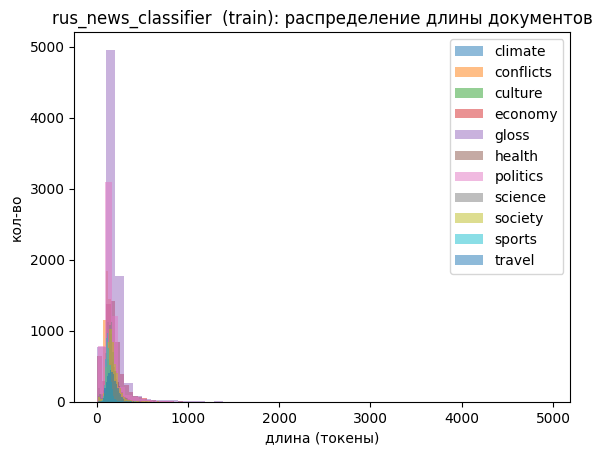

In [27]:
for dom, g in df_len.groupby("domain"):
    plt.hist(g["len_tokens"], bins=50, alpha=0.5, label=dom)

plt.legend()
plt.title("rus_news_classifier  (train): распределение длины документов")
plt.xlabel("длина (токены)")
plt.ylabel("кол-во")
plt.show()

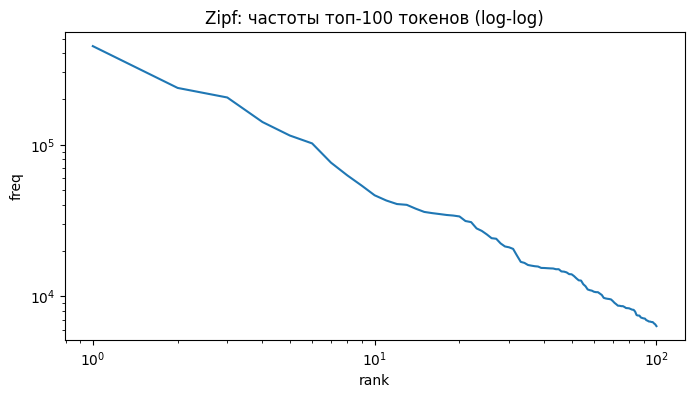

,token,count
0,в,446720
1,и,236727
2,на,204749
3,что,141046
4,с,114927
5,по,101963
6,не,76111
7,из,62720
8,за,53673
9,для,46360


In [28]:
total_counts = Counter()

for text in ds["train"]["news"]:
    total_counts.update(simple_tokenize(text))

top100 = total_counts.most_common(100)
ranks = np.arange(1, 101)
freqs = np.array([c for _,c in top100])

plt.figure(figsize=(8,4))
plt.plot(ranks, freqs)
plt.yscale("log")
plt.xscale("log")
plt.title("Zipf: частоты топ-100 токенов (log-log)")
plt.xlabel("rank")
plt.ylabel("freq")
plt.show()

pd.DataFrame(top100, columns=["token","count"]).head(20)

## А4) Добавление лемматизацию, n-граммы, стоп-слова, и сравние важных токенов

In [29]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.5 MB/s eta 0:00:00


In [33]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [34]:
import pymorphy3
import nltk
from nltk.corpus import stopwords

In [35]:
ru_stop = set(stopwords.words("russian"))
morph = pymorphy3.MorphAnalyzer()

In [36]:
from functools import lru_cache

@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def tokenize_lemmas(text: str) -> List[str]:
    token = []
    words = simple_tokenize(text)
    for w in words:
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        token.append(lemma)
    return token

def add_ngrams(tokens: List[str], n: int = 2) -> List[str]:
    if n <= 1:
        return tokens
    out = list(tokens)
    for k in range(2, n + 1):
        for i in range(len(tokens) - k + 1):
            out.append(" ".join(tokens[i:i+k]))   # или "_".join(...)
    return out

def top_log_odds_words_lemmas(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(tokenize_lemmas(t))
    for t in texts_b:
        cb.update(tokenize_lemmas(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

In [37]:
print(tokenize_lemmas(text_science[0])[:30])
print(len(tokenize_lemmas(text_science[0])))

['год', 'выпустить', 'специальный', 'версия', 'бюджетный', 'компьютер', 'сообщать', 'издание', 'журналист', 'выяснить', 'операционный', 'система', 'пк', 'экран', 'иметь', 'особый', 'версия', 'рассчитать', 'слабый', 'компьютер', 'дать', 'система', 'разрабатываться', 'название', 'итог', 'менеджер', 'корпорация', 'решить', 'отказаться', 'ос']
142


In [38]:
pos, neg = top_log_odds_words_lemmas(text_science, text_sports, top_n=30, alpha=0.1)
print("Топ-слова для science (против sci):")
display(pd.DataFrame(pos, columns=["word", "Δ(sci-spo)"]))
print("Топ-слова для sport (против spo):")
display(pd.DataFrame(neg, columns=["word", "Δ(sci-spo)"]))

Топ-слова для science (против sci):


,word,Δ(sci-spo)
0,обновление,9.045754
1,ос,8.925977
2,девайс,8.761561
3,процессор,8.431916
4,разработчик,8.395773
5,двигатель,8.366204
6,пк,8.332471
7,гаджет,8.302623
8,модуль,8.283934
9,консоль,8.283934


Топ-слова для sport (против spo):


,word,Δ(sci-spo)
0,поединок,-9.887853
1,спортсменка,-9.818171
2,нхл,-9.641463
3,хоккейный,-9.426681
4,фигуристка,-9.319090
5,валиев,-9.309802
6,чемпионка,-9.247935
7,футболист,-9.211835
8,форвард,-9.195529
9,хоккеист,-9.160549


## А5) Напишите 5 наблюдений:
- после лемматизации стали популярны более простые слова, не названия
- лемматизация без кэширования на больших текстах длительна
- без стоп-слов самые популярные слова это союзы
-  n-граммы не попали в сравнение ***science*** и ***sports***
- при сравнение слов ***sci*** и ***spo***  в топ 30 каждое слово можно точно отнести к каждой теметики

# Часть B — Наивный Байес, метрики и перенос (prose → poetry)

## B1) Выберить 2 автора (русский) : Михаил Лермонтов vs Иван Тургенев

**Михаил Лермонтов**
- проза: «Герой нашего времени»
- поэзия: «Мцыри», «Демон», «Парус»

**Иван Тургенев**
- проза: «Отцы и дети»
- поэзия: «Стихотворения в прозе», «Параша», «Андрей»


In [39]:
import gdown
import requests

In [49]:
# Лермонтов
lermontov_prose_id = "1-5cXJSvLk3qJgeENrj5J5GIK0wtTQ9mt" # Герой нашего времени
lermontov_poetry_id = "1hFoMpCfhGbULrzGHR3kUmrjpgYnVeke0" # Мцыри
lermontov_prose_url = f"https://drive.google.com/uc?export=download&id={lermontov_prose_id}"
lermontov_poetry_url = f"https://drive.google.com/uc?export=download&id={lermontov_poetry_id}"

# Тургенев
turgenev_prose_id = "1yK_X1hZyrZYmLvCwojSvvkeHDJieUhLD" # Отцы и дети
turgenev_poetry_id = "1IPE5EVOJXPTPGRzZsEpAvBSc9nxRPouH" # Стихотворения в прозе
turgenev_prose_url = f"https://drive.google.com/uc?export=download&id={turgenev_prose_id}"
turgenev_poetry_url = f"https://drive.google.com/uc?export=download&id={turgenev_poetry_id}"

In [50]:
lermontov_prose_file = gdown.download(lermontov_prose_url, quiet=False)
with open(lermontov_prose_file, 'r', encoding='utf-8') as f:
    lermontov_prose = f.read()[:100000]

lermontov_poetry_file = gdown.download(lermontov_poetry_url, quiet=False)
with open(lermontov_poetry_file, 'r', encoding='utf-8') as f:
    lermontov_poetry = f.read()[:100000]

Downloading...
From: https://drive.google.com/uc?export=download&id=1-5cXJSvLk3qJgeENrj5J5GIK0wtTQ9mt
To: /content/lermontov_prose.txt
100%|██████████| 118k/118k [00:00<00:00, 60.5MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1hFoMpCfhGbULrzGHR3kUmrjpgYnVeke0
To: /content/lermontov_poetry.txt
100%|██████████| 13.7k/13.7k [00:00<00:00, 28.9MB/s]


In [54]:
print("Lermontov prose:", lermontov_prose[:200] + "\n")
print("Lermontov poetry:", lermontov_poetry[:200])

Lermontov prose: Я ехал на перекладных из Тифлиса. Вся поклажа моей тележки состояла из одного небольшого чемодана, который до половины был набит путевыми записками о Грузии. Большая часть из них, к счастию для вас, п

Lermontov poetry: 1
Немного лет тому назад,
Там, где, сливаяся, шумят,
Обнявшись, будто две сестры,
Струи Арагвы и Куры,
Был монастырь. Из-за горы
И нынче видит пешеход
Столбы обрушенных ворот,
И башни, и церковный сво


In [52]:
turgenev_prose_file = gdown.download(turgenev_prose_url, quiet=False)
with open(turgenev_prose_file, 'r', encoding='utf-8') as f:
    turgenev_prose = f.read()[:100000]

turgenev_poetry_file = gdown.download(turgenev_poetry_url, quiet=False)
with open(turgenev_poetry_file, 'r', encoding='utf-8') as f:
    turgenev_poetry = f.read()[:100000]

Downloading...
From: https://drive.google.com/uc?export=download&id=1yK_X1hZyrZYmLvCwojSvvkeHDJieUhLD
To: /content/turgenev_prose.txt
100%|██████████| 67.7k/67.7k [00:00<00:00, 15.6MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1IPE5EVOJXPTPGRzZsEpAvBSc9nxRPouH
To: /content/turgenev_poetry.txt
100%|██████████| 9.37k/9.37k [00:00<00:00, 24.2MB/s]


In [55]:
print("Turgenev prose:", turgenev_prose[:200] + "\n")
print("Turgenev poetry:", turgenev_poetry[:200])

Turgenev prose: I
— Что, Петр, не видать еще? — спрашивал 20-го мая 1859 года, выходя без шапки на низкое крылечко постоялого двора на *** шоссе, барин лет сорока с небольшим, в запыленном пальто и клетчатых панталон

Turgenev poetry: Разговор
Ни на Юнгфрау, ни на Финстерааргорне еще не бывало человеческой ноги.

Вершины Альп... Целая цепь крутых уступов... Самая сердцевина гор.
Над горами бледно-зеленое, светлое, немое небо. Сильн


## B2) Режем на чанки

In [56]:
CHUNK_SIZE = 80  # меньше -> больше документов; попробуйте 80..200

def make_chunks(text: str, chunk_size: int) -> List[str]:
    toks = simple_tokenize(text)
    return chunk_tokens(toks, chunk_size=chunk_size, min_frac=0.5)

lermontov_prose_chunks = make_chunks(lermontov_prose, CHUNK_SIZE)
turgenev_prose_chunks = make_chunks(turgenev_prose, CHUNK_SIZE)

lermontov_poetry_chunks = make_chunks(lermontov_poetry, CHUNK_SIZE)
turgenev_poetry_chunks = make_chunks(turgenev_poetry, CHUNK_SIZE)

print("Чанки (проза):", len(lermontov_prose_chunks), len(turgenev_prose_chunks))
print("Чанки (поэзия):", len(lermontov_poetry_chunks), len(turgenev_poetry_chunks))

# метки: 0 = Poe, 1 = Wilde
X_prose = lermontov_prose_chunks + turgenev_prose_chunks
y_prose = np.array([0]*len(lermontov_prose_chunks) + [1]*len(turgenev_prose_chunks))

X_poetry = lermontov_poetry_chunks + turgenev_poetry_chunks
y_poetry = np.array([0]*len(lermontov_poetry_chunks) + [1]*len(turgenev_poetry_chunks))

author_names = ["Lermontov", "Turgenev"]


Чанки (проза): 133 69
Чанки (поэзия): 16 11


## B3) Обучите MultinomialNB и отчитайтесь

In [57]:
# Train/Valid split (внутридоменный: проза → проза)

Xtr, Xva, ytr, yva = train_test_split(
    X_prose, y_prose, test_size=0.25, random_state=RANDOM_STATE, stratify=y_prose
)

print("Train chunks:", len(Xtr), "Valid chunks:", len(Xva))

Train chunks: 151 Valid chunks: 51


In [58]:
# B4-baseline) Multinomial NB (counts) — без предобработки

nb_counts_base = Pipeline([
    ("vec", CountVectorizer(
        # всё по умолчанию:
        # lowercase=True, token_pattern=...,
        # stop_words=None, min_df=1, max_df=1.0, ngram_range=(1,1)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_base.fit(Xtr, ytr)
pred_va_base = nb_counts_base.predict(Xva)

print("BASE In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va_base))
print(classification_report(yva, pred_va_base, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va_base))

BASE In-domain (PROSE→PROSE) accuracy: 0.9803921568627451
              precision    recall  f1-score   support

   Lermontov       0.97      1.00      0.99        34
    Turgenev       1.00      0.94      0.97        17

    accuracy                           0.98        51
   macro avg       0.99      0.97      0.98        51
weighted avg       0.98      0.98      0.98        51

Confusion matrix:
 [[34  0]
 [ 1 16]]


По confusion matrix:
- Лермонтов/Лермонтов TP модель предсказала 34 раз верно, Лермонтов/Тугренев FN 0 раз неверно
- Тугренев/Лермонтов FP модель предсказала 1 раз неверно, Тугренев/Тугренев TN 16 раз верно

precision = TP / (TP + FP) = 1.00

recall = TP / (TP + FN) = 0.98


F1 = 2 · precision · recall / (precision + recall) = 0.99

## B4) Покажите top-20 важнейших токенов на основе Δ(w).

In [59]:
#  Самые важные токены для NB: Δ(w)=logP(w|Lermonov)-logP(w|Tugrenev)

vec = nb_counts_base.named_steps["vec"]
clf = nb_counts_base.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_lermonov = np.argsort(-delta)[:top_n]
top_turgenev = np.argsort(delta)[:top_n]  # самые отрицательные

df_lermonov = pd.DataFrame({"token": feature_names[top_lermonov], "Δ": delta[top_lermonov]})
df_turgenev = pd.DataFrame({"token": feature_names[top_turgenev], "Δ": delta[top_turgenev]})

print("Топ-токены для Лермонтова")
display(df_lermonov)
print("Топ-токены для Тугренева")
display(df_turgenev)

Топ-токены для Лермонтова


,token,Δ
0,казбич,4.858872
1,азамат,4.814617
2,штабс,4.768312
3,печорин,4.365214
4,капитан,4.291651
5,александрович,4.291651
6,верно,4.212245
7,григорий,4.212245
8,чтоб,4.212245
9,знаете,4.125984


Топ-токены для Тугренева


,token,Δ
0,николай,-6.577507
1,аркадий,-6.577507
2,базаров,-5.835819
3,павел,-5.600826
4,промолвил,-4.977995
5,папаша,-4.977995
6,слегка,-4.846226
7,проговорил,-4.846226
8,прокофьич,-4.694420
9,аркаша,-4.515371


## B5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.

Добавим более «практичную» предобработку:

удаление стоп-слов (встроенный список английских),
фильтрация слишком частых слов max_df,
фильтрация редких min_df,
добавим биграммы (1,2) — часто помогает на авторстве.

In [60]:
@lru_cache(maxsize=200_000)
def lemma_cached(w: str) -> str:
    return morph.parse(w)[0].normal_form

def tokenize_lemmas(text: str) -> List[str]:
    tokens = []
    for w in simple_tokenize(text.lower()):
        if w in ru_stop:
            continue
        lemma = lemma_cached(w)
        if lemma in ru_stop:
            continue
        tokens.append(lemma)
    return tokens

vec = CountVectorizer(
    tokenizer=tokenize_lemmas,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

In [61]:
# B4) Multinomial NB (counts) + улучшенная предобработка

nb_counts = Pipeline([
    ("vec", vec),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts.fit(Xtr, ytr)
pred_va = nb_counts.predict(Xva)

print("In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va))
print(classification_report(yva, pred_va, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va))

In-domain (PROSE→PROSE) accuracy: 1.0
              precision    recall  f1-score   support

   Lermontov       1.00      1.00      1.00        34
    Turgenev       1.00      1.00      1.00        17

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51

Confusion matrix:
 [[34  0]
 [ 0 17]]


In [62]:
#  Самые важные токены для NB: Δ(w)=logP(w|Lermonov)-logP(w|Tugrenev)

vec = nb_counts_base.named_steps["vec"]
clf = nb_counts_base.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_lermonov = np.argsort(-delta)[:top_n]
top_turgenev = np.argsort(delta)[:top_n]  # самые отрицательные

df_lermonov = pd.DataFrame({"token": feature_names[top_lermonov], "Δ": delta[top_lermonov]})
df_turgenev = pd.DataFrame({"token": feature_names[top_turgenev], "Δ": delta[top_turgenev]})

print("Топ-токены для Лермонтова")
display(df_lermonov)
print("Топ-токены для Тугренева")
display(df_turgenev)

Топ-токены для Лермонтова


,token,Δ
0,казбич,4.858872
1,азамат,4.814617
2,штабс,4.768312
3,печорин,4.365214
4,капитан,4.291651
5,александрович,4.291651
6,верно,4.212245
7,григорий,4.212245
8,чтоб,4.212245
9,знаете,4.125984


Топ-токены для Тугренева


,token,Δ
0,николай,-6.577507
1,аркадий,-6.577507
2,базаров,-5.835819
3,павел,-5.600826
4,промолвил,-4.977995
5,папаша,-4.977995
6,слегка,-4.846226
7,проговорил,-4.846226
8,прокофьич,-4.694420
9,аркаша,-4.515371


## B6) Сделайте domain shift и опишите, что сломалось и что помогло.

In [63]:
# B6) Domain shift: обучаемся на прозе, тестируемся на поэзии

pred_poetry = nb_counts.predict(X_poetry)

print("Domain shift (PROSE→POETRY) accuracy:", accuracy_score(y_poetry, pred_poetry))
print(classification_report(y_poetry, pred_poetry, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_poetry, pred_poetry))

Domain shift (PROSE→POETRY) accuracy: 0.7037037037037037
              precision    recall  f1-score   support

   Lermontov       0.67      1.00      0.80        16
    Turgenev       1.00      0.27      0.43        11

    accuracy                           0.70        27
   macro avg       0.83      0.64      0.61        27
weighted avg       0.80      0.70      0.65        27

Confusion matrix:
 [[16  0]
 [ 8  3]]


По confusion matrix:
- Лермонтов/Лермонтов TP модель предсказала 16 раз верно, Лермонтов/Тугренев FN 0 раз неверно
- Тугренев/Лермонтов FP модель предсказала 8 раз неверно, Тугренев/Тугренев TN 3 раз верно

precision = TP / (TP + FP) = 0.66 -> когда модель говорит "Лермонтов", в 34% случаев это на самом деле Тургенев

recall = TP / (TP + FN) = 1.00 -> → модель всегда правильно определяет Лермонтова, не пропускает его


F1 = 2 · precision · recall / (precision + recall) = 0.8

**Recall:** Модель отлично угадывает Лермонтова (100% случаев), но хуже распознает Тургенева — только 3 из 11 фрагментов определены верно.

**Precision:** Модель часто принимает Тургенева за Лермонтова (8 ложных срабатываний), поэтому точность предсказаний для Лермонтова составляет всего 66%.

## Конец

*Спасибо большое, что Вы проверили мою работу. Если у Вас есть какие-либо вопросы, пожалуйста напишите через телеграм  **[@ngocleltt](https://t.me/ngocleltt)***. Рада и готова ответить!